Implementing Simple Linear Regression

Coefficient: 4.0201501382852625
Intercept: 30.587119715527464
MAE: 0.25839589095219156
RMSE: 0.2757933427545028
R2 Score: 0.9997923065196695
Regression Equation: Final_Marks = 4.0201501382852625 * Study_Hours + 30.587119715527464


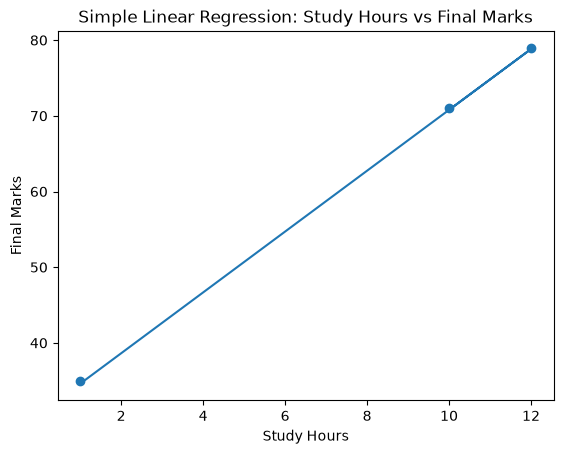

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Create the dataset
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "Attendance": [55, 60, 65, 62, 70, 72, 75, 80, 78, 82, 85, 88, 90, 92, 95],
    "Assignment_Score": [40, 45, 50, 48, 55, 58, 62, 67, 65, 70, 74, 78, 80, 85, 90],
    "Student_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115],
    "Final_Marks": [35, 40, 43, 45, 50, 54, 60, 64, 66, 71, 74, 79, 82, 87, 92]
}

df = pd.DataFrame(data)

# Select ONE independent variable
X = df[['Study_Hours']]
y = df['Final_Marks']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Simple Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Print coefficient and intercept
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

# Evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Regression equation
print(
    "Regression Equation: Final_Marks =",
    model.coef_[0],
    "* Study_Hours +",
    model.intercept_
)

# Plot
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Simple Linear Regression: Study Hours vs Final Marks")
plt.show()

Implementing Lasso, LassoCV

In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Corrected dataset: all lists now contain exactly 15 elements
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "Attendance": [55, 60, 65, 62, 70, 72, 75, 80, 78, 82, 85, 88, 90, 92, 95],
    "Assignment_Score": [40,45,50,48,55,58,62,67,65,70,74,78,80,85,90,],
    "Student_ID": [101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,],
    "Final_Marks": [35, 40, 43, 45, 50, 54, 60, 64, 66, 71, 74, 79, 82, 87, 92],
}

df = pd.DataFrame(data)

# Exclude 'Student_ID' from training features
x = df[["Study_Hours", "Attendance", "Assignment_Score"]]
y = df["Final_Marks"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = make_pipeline(StandardScaler(), Lasso(alpha=0.1))

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

lasso_model = model.named_steps["lasso"]
coefficient_table = pd.DataFrame(
    {"Predictor": x.columns, "Lasso Coefficient": lasso_model.coef_}
)

print(coefficient_table)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

          Predictor  Lasso Coefficient
0       Study_Hours          10.511777
1        Attendance           0.000000
2  Assignment_Score           6.291250
MAE: 0.6275462040504939
RMSE: 0.6742427157677343
R2 Score: 0.998758668338018


Selecting the best Lambda

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV

model = make_pipeline(
    StandardScaler(),
    LassoCV(
        alphas=[0.001, 0.01, 0.1, 1, 10],
        cv=5,
        max_iter=10000
    )
)

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Study_Hours','Attendance','Assignment_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [19]:
y_pred = model.predict(x_test)

# 2. Extract the trained LassoCV step from the pipeline
lasso_cv_step = model.named_steps["lassocv"]

# 3. Retrieve best alpha and feature coefficients
print("Best Alpha:", lasso_cv_step.alpha_)

coefficients = pd.DataFrame(
    {"Predictor": x_train.columns, "Coefficient": lasso_cv_step.coef_}
)
print("\nModel Coefficients:")
print(coefficients.to_string(index=False))

# 4. Evaluate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Best Alpha: 0.1

Model Coefficients:
       Predictor  Coefficient
     Study_Hours    10.511777
      Attendance     0.000000
Assignment_Score     6.291250

--- Model Evaluation ---
MAE:  0.6275
MSE:  0.4546
RMSE: 0.6742
R²:   0.9988


In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 1. Sample Data Setup
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "Attendance": [55, 60, 65, 62, 70, 72, 75, 80, 78, 82, 85, 88, 90, 92, 95],
    "Assignment_Score": [
        40,
        45,
        50,
        48,
        55,
        58,
        62,
        67,
        65,
        70,
        74,
        78,
        80,
        85,
        90,
    ],
    "Final_Marks": [35, 40, 43, 45, 50, 54, 60, 64, 66, 71, 74, 79, 82, 87, 92],
}

df = pd.DataFrame(data)

X = df[["Study_Hours", "Attendance", "Assignment_Score"]]
y = df["Final_Marks"]

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Create and Train Ridge Pipeline (StandardScaler + Ridge)
ridge_pipeline = make_pipeline(
    StandardScaler(), Ridge(alpha=1.0)  # Set L2 penalty strength alpha
)

ridge_pipeline.fit(X_train, y_train)

# 4. Predict
y_pred = ridge_pipeline.predict(X_test)

# 5. Extract Coefficients and Intercept
ridge_model = ridge_pipeline.named_steps["ridge"]
coefficients = pd.DataFrame(
    {"Predictor": X.columns, "Ridge Coefficient": ridge_model.coef_}
)

print("--- Ridge Model Parameters ---")
print(f"Intercept: {ridge_model.intercept_:.4f}\n")
print(coefficients.to_string(index=False))

# 6. Model Evaluation
print("\n--- Model Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

--- Ridge Model Parameters ---
Intercept: 63.0833

       Predictor  Ridge Coefficient
     Study_Hours           6.197049
      Attendance           4.762028
Assignment_Score           5.476492

--- Model Performance ---
MAE:  0.9133
MSE:  0.9677
RMSE: 0.9837
R²:   0.9974


Convert the coefficients back to Original Units

In [21]:
import numpy as np

# 1. Extract pipeline steps from ridge_pipeline
scaler = ridge_pipeline.named_steps["standardscaler"]
regressor = ridge_pipeline.named_steps["ridge"]

# 2. Convert coefficients & intercept to original units
original_coefficients = np.ravel(regressor.coef_) / scaler.scale_
original_intercept = regressor.intercept_ - np.sum(
    original_coefficients * scaler.mean_
)

print("Ridge Original Intercept:", original_intercept)
print("Ridge Original Coefficients:", original_coefficients)

Ridge Original Intercept: -6.462324530626866
Ridge Original Coefficients: [1.47815544 0.42200819 0.38668967]


In [28]:
import numpy as np
import pandas as pd

# 1. Extract pipeline steps from the LassoCV model
scaler = model.named_steps["standardscaler"]
regressor = model.named_steps["lassocv"]

# 2. Convert coefficients and intercept to original units
original_coefficients = np.ravel(regressor.coef_) / scaler.scale_

original_intercept = regressor.intercept_ - np.sum(
    original_coefficients * scaler.mean_
)

# 3. Display results
print("LassoCV Original Intercept:", original_intercept)
print("LassoCV Original Coefficients:", original_coefficients)

LassoCV Original Intercept: 13.978548870296905
LassoCV Original Coefficients: [2.50732896 0.         0.44421888]
